In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.8 MB/s eta 0:00:00


In [ ]:
!pip install pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 30.8 MB/s eta 0:00:00


In [ ]:
import os
from PIL import Image
from pillow_heif import register_heif_opener
import shutil
register_heif_opener()

folder_dau_vao = '/content/drive/MyDrive/PCB_DETECT/datasets/train/raw'

folder_dau_ra = '/content/drive/MyDrive/PCB_DETECT/datasets/train/images'

def process_images():
    if not os.path.exists(folder_dau_vao):
        print(f"❌ LỖI: Không tìm thấy thư mục '{folder_dau_vao}' trên Drive.")
        print("👉 Hãy kiểm tra lại tên thư mục bạn đã tạo trên Google Drive.")
        return

    if not os.path.exists(folder_dau_ra):
        os.makedirs(folder_dau_ra)
        print(f"✅ Đã tạo thư mục đầu ra: {folder_dau_ra}")

    # Lấy danh sách file
    valid_extensions = ('.heic', '.heif', '.png', '.jpg', '.jpeg')
    files = [f for f in os.listdir(folder_dau_vao) if f.lower().endswith(valid_extensions)]

    # Sắp xếp file theo tên (mặc định)
    files.sort()

    print(f"📂 Tìm thấy {len(files)} ảnh. Đang tiến hành chuyển đổi...\n")

    count = 1
    for filename in files:
        file_path = os.path.join(folder_dau_vao, filename)

        try:
            img = Image.open(file_path)

            new_name = f"{count:04d}.png"
            output_path = os.path.join(folder_dau_ra, new_name)

            img.save(output_path, "PNG")

            if count % 10 == 0 or count == len(files):
                 print(f"   -> Đã xong ảnh thứ {count}: {filename} thành {new_name}")

            count += 1

        except Exception as e:
            print(f"⚠️ Lỗi file {filename}: {e}")

    print(f"\n🎉 HOÀN TẤT! Ảnh đã được lưu tại: {folder_dau_ra}")

process_images()

✅ Đã tạo thư mục đầu ra: /content/drive/MyDrive/PCB_DETECT/datasets/train/images
📂 Tìm thấy 66 ảnh. Đang tiến hành chuyển đổi...

   -> Đã xong ảnh thứ 10: IMG_4818.HEIC thành 0010.png
   -> Đã xong ảnh thứ 20: IMG_4838.heic thành 0020.png
   -> Đã xong ảnh thứ 30: IMG_4848.HEIC thành 0030.png
   -> Đã xong ảnh thứ 40: IMG_4866.HEIC thành 0040.png
   -> Đã xong ảnh thứ 50: IMG_4876.HEIC thành 0050.png
   -> Đã xong ảnh thứ 60: IMG_4892.HEIC thành 0060.png
   -> Đã xong ảnh thứ 66: IMG_4898.HEIC thành 0066.png

🎉 HOÀN TẤT! Ảnh đã được lưu tại: /content/drive/MyDrive/PCB_DETECT/datasets/train/images
Bạn có thể vào Google Drive để tải thư mục này về.


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.5/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
        data='/content/drive/MyDrive/PCB_DETECT/datasets/dataset_lm2596/data.yaml',
        epochs=100,
        imgsz=640,
        patience=20,
        batch=16,
        project='runs/detect',
        name='lm2596_training',


        degrees=15.0,
        translate=0.1,
        scale=0.5,
        flipud=0.5,
        fliplr=0.5,

        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,

        mosaic=1.0,
        mixup=0.0,
        copy_paste=0.0,
        )

print("Training hoàn tất.")

In [ ]:
import os
from google.colab import files

# 1. Nén thư mục runs thành runs.zip
print("Đang nén dữ liệu...")
!zip -r /content/runs.zip /content/runs

# 2. Tải về máy
print("Đang tải xuống...")
files.download('/content/runs.zip')

# **TEST**


## SET UP

In [2]:
!pip install ultralytics opencv-python-headless matplotlib pydantic

import os
from pathlib import Path

BASE_DIR = Path("/content/backend_sim")
ARTIFACTS_DIR = BASE_DIR / "data/artifacts"
TEMPLATES_DIR = ARTIFACTS_DIR / "templates"
DATASET_DIR = BASE_DIR / "data/dataset"

os.makedirs(TEMPLATES_DIR, exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)

print(" Đã tạo môi trường giả lập tại:", BASE_DIR)

 Đã tạo môi trường giả lập tại: /content/backend_sim


In [4]:
import shutil


MODEL_FILE = "/content/drive/MyDrive/PCB_DETECT/best.pt"
REF_IMAGE = "/content/drive/MyDrive/PCB_DETECT/ref.png"
TEST_IMAGE = "/content/drive/MyDrive/PCB_DETECT/test3.jpg"

if os.path.exists(MODEL_FILE):
    shutil.copy(MODEL_FILE, ARTIFACTS_DIR / "best.pt")
    print(f"✅ Đã nạp Model: {MODEL_FILE}")
else:
    print(f"❌ Chưa thấy file {MODEL_FILE}. Hãy upload lên Colab trước!")

if os.path.exists(REF_IMAGE):
    shutil.copy(REF_IMAGE, DATASET_DIR / "ref_sample.jpg")
    print(f"✅ Đã nạp ảnh Reference: {REF_IMAGE}")
else:
    print(f"❌ Chưa thấy file {REF_IMAGE}")

import cv2
import matplotlib.pyplot as plt

if os.path.exists(TEST_IMAGE):
    test_img_bgr = cv2.imread(TEST_IMAGE)
    print(f"✅ Đã nạp ảnh Test: {TEST_IMAGE} (Kích thước: {test_img_bgr.shape})")
else:
    print(f"❌ Chưa thấy file {TEST_IMAGE}")

def show_img(img, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

✅ Đã nạp Model: /content/drive/MyDrive/PCB_DETECT/best.pt
✅ Đã nạp ảnh Reference: /content/drive/MyDrive/PCB_DETECT/ref.png
✅ Đã nạp ảnh Test: /content/drive/MyDrive/PCB_DETECT/test3.jpg (Kích thước: (2048, 1536, 3))


In [5]:
from ultralytics import YOLO
import numpy as np
import json
from datetime import datetime
from pydantic import BaseModel
from typing import List, Optional

# --- MOCK SETTINGS ---
class Settings:
    artifacts_dir = ARTIFACTS_DIR

settings = Settings()

# --- DATA MODELS ---
class ComponentTemplate(BaseModel):
    id: int
    label: str
    box: List[float] # xywh normalized

class BoardProfile(BaseModel):
    boardName: str
    reference_image_path: str
    components: List[ComponentTemplate]

# --- SERVICE 1: TRAINING (TẠO PROFILE) ---
class SimTrainingService:
    def __init__(self):
        self.model = YOLO(str(ARTIFACTS_DIR / "best.pt"))

    def create_profile(self, image_path, board_name="LM2596_TEST"):
        print(f"Bắt đầu quét Layout mạch: {board_name}...")

        img = cv2.imread(str(image_path))

        # Detect
        results = self.model(img, verbose=False)
        components = []

        for r in results:
            for idx, box in enumerate(r.boxes):
                # Lấy box xywh chuẩn hóa (0-1)
                xywhn = box.xywhn[0].tolist()
                cls_id = int(box.cls[0])
                components.append(ComponentTemplate(id=idx, label=str(cls_id), box=xywhn))

        print(f"Tìm thấy {len(components)} linh kiện.")

        # Lưu Profile
        ref_save_path = TEMPLATES_DIR / f"{board_name}_ref.jpg"
        cv2.imwrite(str(ref_save_path), img)

        profile = BoardProfile(
            boardName=board_name,
            reference_image_path=str(ref_save_path),
            components=components
        )

        json_path = TEMPLATES_DIR / f"{board_name}.json"
        with open(json_path, "w") as f:
            f.write(profile.json())

        with open(ARTIFACTS_DIR / "active_profile.txt", "w") as f:
            f.write(board_name)

        print(f"Đã tạo Profile thành công tại: {json_path}")
        return profile

# --- SERVICE 2: INFERENCE (ALIGN + CHECK) ---
class SimInferenceService:
    def __init__(self):
        self.model = YOLO(str(ARTIFACTS_DIR / "best.pt"))
        self.sift = cv2.SIFT_create()
        self.profile = None
        self.ref_img = None
        self.ref_kp = None
        self.ref_des = None
        self.load_profile()

    def load_profile(self):
        try:
            with open(ARTIFACTS_DIR / "active_profile.txt", "r") as f:
                name = f.read().strip()
            with open(TEMPLATES_DIR / f"{name}.json", "r") as f:
                data = json.load(f)
                self.profile = BoardProfile(**data)

            self.ref_img = cv2.imread(self.profile.reference_image_path)
            mask_ref = self.create_pcb_mask(self.ref_img)
            gray_ref = cv2.cvtColor(self.ref_img, cv2.COLOR_BGR2GRAY)
            self.ref_kp, self.ref_des = self.sift.detectAndCompute(gray_ref, mask_ref)
            print(f" Đã load profile: {name}")
        except Exception as e:
            print(f" Lỗi load profile: {e}")

    def create_pcb_mask(self, img):
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        lower_blue = np.array([90, 50, 50])
        upper_blue = np.array([130, 255, 255])
        mask = cv2.inRange(hsv, lower_blue, upper_blue)
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        return cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel)

    def align_image(self, target_img):
        if self.ref_img is None or self.ref_des is None: return target_img
        h_ref, w_ref = self.ref_img.shape[:2]
        h_tgt, w_tgt = target_img.shape[:2]

        if (w_ref > h_ref) and (h_tgt > w_tgt):
            target_img = cv2.rotate(target_img, cv2.ROTATE_90_CLOCKWISE)
        elif (h_ref > w_ref) and (w_tgt > h_tgt):
            target_img = cv2.rotate(target_img, cv2.ROTATE_90_CLOCKWISE)

        mask_tgt = self.create_pcb_mask(target_img)
        gray_tgt = cv2.cvtColor(target_img, cv2.COLOR_BGR2GRAY)
        kp2, des2 = self.sift.detectAndCompute(gray_tgt, mask_tgt)

        if des2 is None or len(kp2) < 5: return target_img

        bf = cv2.BFMatcher()
        matches = bf.knnMatch(self.ref_des, des2, k=2)
        good = []
        for m, n in matches:
            if m.distance < 0.75 * n.distance: good.append(m)

        if len(good) > 10:
            src_pts = np.float32([self.ref_kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

            # Affine Partial (Xoay + Dịch + Scale)
            M, inliers = cv2.estimateAffinePartial2D(dst_pts, src_pts)
            if M is not None:
                return cv2.warpAffine(target_img, M, (w_ref, h_ref), flags=cv2.INTER_CUBIC)
        return target_img

    def calculate_iou(self, box1, box2):
        """Tính chỉ số chồng lấn (Intersection over Union)"""
        # box: [x_center, y_center, w, h] -> convert to x1, y1, x2, y2
        b1_x1, b1_y1 = box1[0] - box1[2]/2, box1[1] - box1[3]/2
        b1_x2, b1_y2 = box1[0] + box1[2]/2, box1[1] + box1[3]/2

        b2_x1, b2_y1 = box2[0] - box2[2]/2, box2[1] - box2[3]/2
        b2_x2, b2_y2 = box2[0] + box2[2]/2, box2[1] + box2[3]/2

        # Tọa độ vùng giao nhau
        x_left = max(b1_x1, b2_x1)
        y_top = max(b1_y1, b2_y1)
        x_right = min(b1_x2, b2_x2)
        y_bottom = min(b1_y2, b2_y2)

        if x_right < x_left or y_bottom < y_top:
            return 0.0

        intersection_area = (x_right - x_left) * (y_bottom - y_top)
        b1_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
        b2_area = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)

        iou = intersection_area / float(b1_area + b2_area - intersection_area)
        return iou

    def verify_visual(self, aligned_img, box_norm):
        h, w = aligned_img.shape[:2]
        cx, cy, bw, bh = box_norm
        x1 = max(0, int((cx - bw/2) * w))
        y1 = max(0, int((cy - bh/2) * h))
        x2 = min(w, int((cx + bw/2) * w))
        y2 = min(h, int((cy + bh/2) * h))
        if x2 <= x1 or y2 <= y1: return 0.0
        try:
            roi_test = aligned_img[y1:y2, x1:x2]
            roi_ref = self.ref_img[y1:y2, x1:x2]
            g_test = cv2.cvtColor(roi_test, cv2.COLOR_BGR2GRAY)
            g_ref = cv2.cvtColor(roi_ref, cv2.COLOR_BGR2GRAY)
            res = cv2.matchTemplate(g_test, g_ref, cv2.TM_CCOEFF_NORMED)
            return res[0][0]
        except: return 0.0

    def analyze(self, image):
        print("\n" + "="*50)
        print("MATCHING 1-1 ")
        print("="*50)

        # 1. Align
        aligned = self.align_image(image)
        h, w = aligned.shape[:2]
        debug_img = aligned.copy()

        # 2. Detect YOLO
        print("Đang chạy YOLO...")
        results = self.model(aligned, verbose=False, conf=0.25)

        detected_candidates = []
        for r in results:
            for i, box in enumerate(r.boxes):
                xywh = box.xywhn[0].tolist()
                conf = float(box.conf[0])
                detected_candidates.append({
                    'id': i,
                    'box': xywh,
                    'conf': conf,
                    'is_used': False
                })

                mx, my, mw, mh = xywh
                x1, y1 = int((mx - mw/2) * w), int((my - mh/2) * h)
                x2, y2 = int((mx + mw/2) * w), int((my + mh/2) * h)
                cv2.rectangle(debug_img, (x1, y1), (x2, y2), (255, 255, 0), 1)

        print(f"👉 Tổng số box YOLO: {len(detected_candidates)}")
        missing = []

        # 3. So khớp từng linh kiện (Matching Loop)
        for temp_comp in self.profile.components:
            tx, ty, tw, th = temp_comp.box

            x1_t = int((tx - tw/2) * w)
            y1_t = int((ty - th/2) * h)
            x2_t = int((tx + tw/2) * w)
            y2_t = int((ty + th/2) * h)
            cv2.rectangle(debug_img, (x1_t, y1_t), (x2_t, y2_t), (100, 100, 100), 1)

            matched_candidate = None
            best_score = -999

            for candidate in detected_candidates:
                if candidate['is_used']:
                    continue

                iou = self.calculate_iou(temp_comp.box, candidate['box'])
                dx, dy, _, _ = candidate['box']
                dist = np.sqrt((tx - dx)**2 + (ty - dy)**2)

                # ĐIỀU KIỆN KHỚP :
                # 1. IoU > 0 (Có chạm nhau)
                # 2. HOẶC Khoảng cách cực gần < 0.06 (6% chiều rộng ảnh)
                is_match = (iou > 0.01) or (dist < 0.06)

                if is_match:
                    score = iou + (1.0 - dist)
                    if score > best_score:
                        best_score = score
                        matched_candidate = candidate

            yolo_found = False
            if matched_candidate:
                yolo_found = True
                matched_candidate['is_used'] = True

            is_present = False
            final_reason = "MISSING"

            if yolo_found:
                mx, my, mw, mh = matched_candidate['box']
                cx_ref, cy_ref = int(tx*w), int(ty*h)
                cx_det, cy_det = int(mx*w), int(my*h)

                if abs(cx_ref - cx_det) > 2 or abs(cy_ref - cy_det) > 2:
                    cv2.line(debug_img, (cx_ref, cy_ref), (cx_det, cy_det), (0, 255, 255), 1)

                matched_box = matched_candidate['box']
                matched_conf = matched_candidate['conf']

                vis_score = self.verify_visual(aligned, matched_box)

                # Logic phán đoán
                if vis_score > 0.15:
                    is_present = True
                    final_reason = f"OK"
                elif matched_conf > 0.4:
                    is_present = True
                    final_reason = f"OK"
                else:
                    is_present = False
                    final_reason = f"BAD"

            if is_present and matched_candidate:
                # CÓ:
                mx, my, mw, mh = matched_candidate['box']
                x1 = int((mx - mw/2) * w)
                y1 = int((my - mh/2) * h)
                x2 = int((mx + mw/2) * w)
                y2 = int((my + mh/2) * h)
                cv2.rectangle(debug_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(debug_img, final_reason, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
            else:
                # THIẾU:
                cv2.rectangle(debug_img, (x1_t, y1_t), (x2_t, y2_t), (0, 0, 255), 2)

                label = final_reason
                if not yolo_found: label = "MISSING"

                cv2.putText(debug_img, label, (x1_t, y1_t-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
                missing.append(temp_comp.id)

        return debug_img, missing


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Bắt đầu quét Layout mạch: LM2596_TEST...
Tìm thấy 11 linh kiện.
Đã tạo Profile thành công tại: /content/backend_sim/data/artifacts/templates/LM2596_TEST.json

--- NỘI DUNG FILE JSON ĐÃ TẠO ---
{
  "boardName": "LM2596_TEST",
  "reference_image_path": "/content/backend_sim/data/artifacts/templates/LM2596_TEST_ref.jpg",
  "components": [
    {
      "id": 0,
      "label": "0",
      "box": [
        0.5787266492843628,
        0.5493000745773315,
        0.1422061026096344,
        0.10878868401050568
      ]
    },
    {
      "id": 1,
      "label": "0",
      "box": [
        0.3994112014770508,
        0.45881059765815735,
        0.14589646458625793,
        0.11131419986486435
      ]
    },
    {
      "id": 2,
      "label": "0",
      "box": [
        0.7447956800460815,
        0.5168610215187073,
        0.1058480367064476,
        0.07768573611974716
      ]
    },
    {
      "id": 3,
      "label": "0",
      "box": [
        0.5972223281860352,
        0.4404419958591461,

/tmp/ipython-input-972182828.py:60: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  f.write(profile.json())


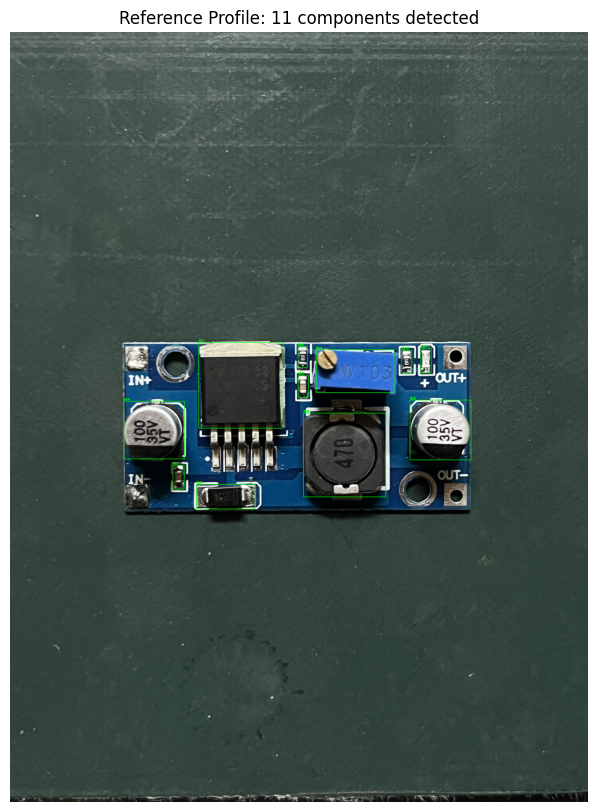

In [6]:
import cv2
import matplotlib.pyplot as plt

trainer = SimTrainingService()

ref_path = DATASET_DIR / "ref_sample.jpg"

try:
    profile = trainer.create_profile(ref_path)

    print("\n--- NỘI DUNG FILE JSON ĐÃ TẠO ---")
    print(profile.model_dump_json(indent=2))
    print("\n--- TRỰC QUAN HÓA: MẠCH MẪU ĐÃ HỌC ---")
    img = cv2.imread(str(ref_path))
    h, w = img.shape[:2]

    for comp in profile.components:
        cx, cy, bw, bh = comp.box

        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        cv2.putText(img, f"ID:{comp.id}", (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Reference Profile: {len(profile.components)} components detected")
    plt.axis('off')
    plt.show()

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f" Có lỗi xảy ra: {e}")

 Đã load profile: LM2596_TEST

MATCHING 1-1 
Đang chạy YOLO...
👉 Tổng số box YOLO: 9


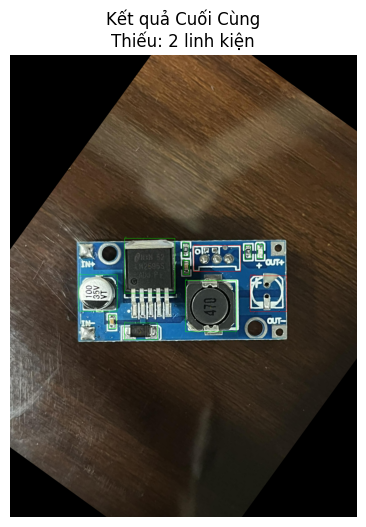

In [7]:
# Khởi tạo
inferencer = SimInferenceService()

if 'test_img_bgr' in globals():
    # Chạy phân tích
    result_img, missing_ids = inferencer.analyze(test_img_bgr)

    # Hiển thị
    show_img(result_img, f"Kết quả Cuối Cùng\nThiếu: {len(missing_ids)} linh kiện")
else:
    print("⚠️ Hãy upload ảnh test.jpg trước")

##TEST YOLO


🚀 Đang load model từ: /content/drive/MyDrive/PCB_DETECT/best.pt...
📸 Đang nhận diện ảnh: /content/drive/MyDrive/PCB_DETECT/0059.png...

image 1/1 /content/drive/MyDrive/PCB_DETECT/0059.png: 640x480 9 componentss, 40.9ms
Speed: 20.2ms preprocess, 40.9ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 480)

✅ KẾT QUẢ: Tìm thấy 9 linh kiện!
   🔹 Linh kiện #1: Class=0 | Độ tin cậy=0.93 | Vị trí=[1271.9285888671875, 1732.281005859375, 410.523193359375, 433.2169189453125]
   🔹 Linh kiện #2: Class=0 | Độ tin cậy=0.93 | Vị trí=[1779.799560546875, 2062.6923828125, 411.8248291015625, 420.2896728515625]
   🔹 Linh kiện #3: Class=0 | Độ tin cậy=0.89 | Vị trí=[856.9239501953125, 1932.165283203125, 289.0936279296875, 313.6063232421875]
   🔹 Linh kiện #4: Class=0 | Độ tin cậy=0.72 | Vị trí=[1194.865966796875, 2270.91064453125, 269.64892578125, 121.657958984375]
   🔹 Linh kiện #5: Class=0 | Độ tin cậy=0.70 | Vị trí=[2188.81494140625, 1633.8154296875, 56.058837890625, 117.7835693359375]
   🔹

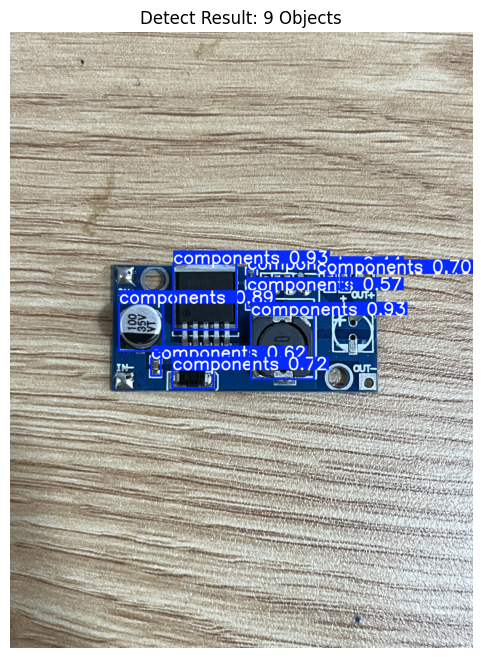

In [21]:
# yolo
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

MODEL_PATH = "/content/drive/MyDrive/PCB_DETECT/best.pt"

IMAGE_PATH = "/content/drive/MyDrive/PCB_DETECT/0059.png"


if not os.path.exists(MODEL_PATH):
    print(f" Lỗi: Không tìm thấy model tại '{MODEL_PATH}'")

if not os.path.exists(IMAGE_PATH):
    print(f" Lỗi: Không tìm thấy ảnh test tại '{IMAGE_PATH}'")


print(f" Đang load model từ: {MODEL_PATH}...")
model = YOLO(MODEL_PATH)

print(f" Đang nhận diện ảnh: {IMAGE_PATH}...")
results = model.predict(IMAGE_PATH, conf=0.25)

for result in results:
    boxes = result.boxes
    print(f"\n KẾT QUẢ: Tìm thấy {len(boxes)} linh kiện!")

    for i, box in enumerate(boxes):
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        xywh = box.xywh[0].tolist()

        print(f"   🔹 Linh kiện #{i+1}: Class={cls_id} | Độ tin cậy={conf:.2f} | Vị trí={xywh}")


    img_result = result.plot()
    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Detect Result: {len(boxes)} Objects")
    plt.show()

## Debug Align + Detect

🚀 Bắt đầu Debug Align + Detect...
🔹 Keypoints Ref: 813 | Keypoints Test: 3788
🔹 Số điểm khớp (Matches): 55
✅ Tìm thấy góc xoay: -1.05 độ
💾 Đã lưu ảnh sau khi xoay tại: debug_aligned.jpg
running YOLO on aligned image...

0: 640x480 9 componentss, 6.5ms
Speed: 2.8ms preprocess, 6.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)


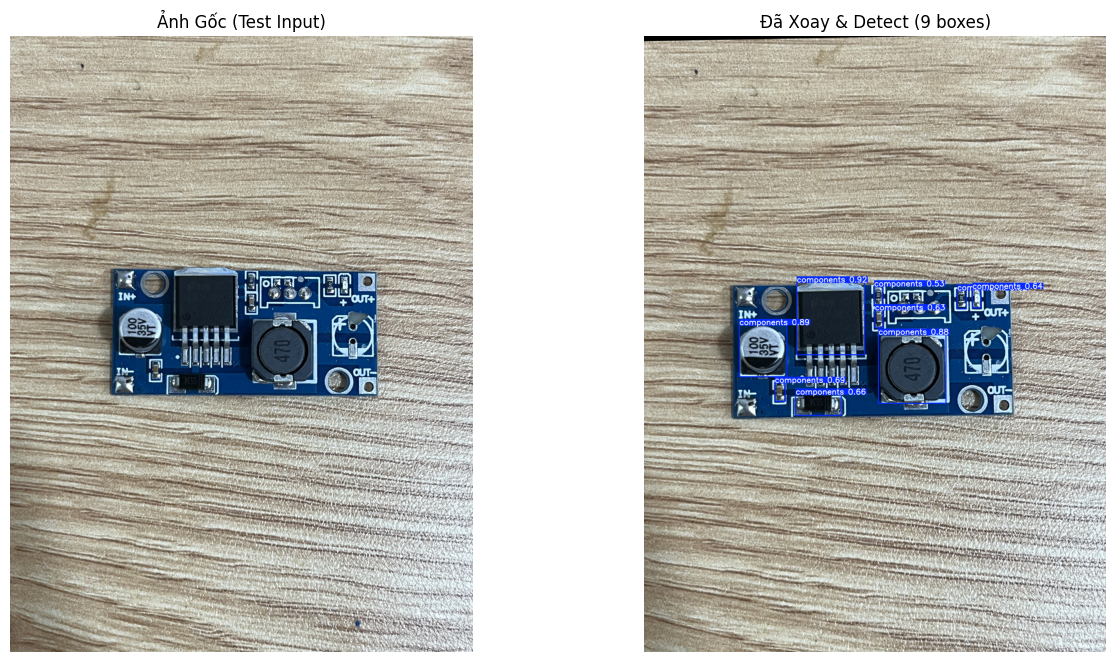

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os


MODEL_PATH = "/content/drive/MyDrive/PCB_DETECT/best.pt"
REF_PATH = "/content/drive/MyDrive/PCB_DETECT/ref.png"
TEST_PATH = "/content/drive/MyDrive/PCB_DETECT/0059.png"

def create_pcb_mask(img):
    """Tạo mask lọc nền xanh lá"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([130, 255, 255])
    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel)

def debug_pipeline():
    print(f"🚀 Bắt đầu Debug Align + Detect...")

    ref_img = cv2.imread(REF_PATH)
    test_img = cv2.imread(TEST_PATH)

    if ref_img is None or test_img is None:
        print("❌ Lỗi: Không tìm thấy ảnh Ref hoặc Test.")
        return

    sift = cv2.SIFT_create()

    # Tính Keypoint cho Ref
    mask_ref = create_pcb_mask(ref_img)
    kp1, des1 = sift.detectAndCompute(cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY), mask_ref)

    # Tính Keypoint cho Test
    mask_test = create_pcb_mask(test_img)
    kp2, des2 = sift.detectAndCompute(cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY), mask_test)

    print(f"🔹 Keypoints Ref: {len(kp1)} | Keypoints Test: {len(kp2)}")

    # Match & Align
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)
    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    print(f"🔹 Số điểm khớp (Matches): {len(good)}")

    aligned_img = test_img.copy()

    if len(good) > 10:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        # Dùng Partial Affine (Chỉ xoay, dịch, scale)
        M, inliers = cv2.estimateAffinePartial2D(dst_pts, src_pts)

        if M is not None:
            angle = np.arctan2(M[1, 0], M[0, 0]) * 180 / np.pi
            print(f"Tìm thấy góc xoay: {angle:.2f} độ")

            h, w = ref_img.shape[:2]

            aligned_img = cv2.warpAffine(test_img, M, (w, h), flags=cv2.INTER_CUBIC)
        else:
            print(" Không tìm thấy ma trận biến đổi hợp lệ.")
    else:
        print(" Không đủ điểm khớp để Align.")

    debug_path = "debug_aligned.jpg"
    cv2.imwrite(debug_path, aligned_img)
    print(f" Đã lưu ảnh sau khi xoay tại: {debug_path}")

    print("running YOLO on aligned image...")
    model = YOLO(MODEL_PATH)

    results = model(aligned_img, conf=0.25)

    for r in results:
        plotted = r.plot(line_width=5, font_size=10)

        plt.figure(figsize=(15, 8))

        plt.subplot(1, 2, 1)
        plt.title("Ảnh Gốc (Test Input)")
        plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title(f"Đã Xoay & Detect ({len(r.boxes)} boxes)")
        plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.show()

debug_pipeline()

✅ Đã load profile: LM2596_TEST

🚀 DEBUG GLOBAL BEST MATCHING (Visual Clean)
📸 YOLO detecting...
👉 YOLO candidates: 9
✅ Comp 9 ↔ Box 5 (IoU=0.94, Dist=0.00)
✅ Comp 1 ↔ Box 0 (IoU=0.89, Dist=0.00)
✅ Comp 5 ↔ Box 6 (IoU=0.86, Dist=0.00)
✅ Comp 8 ↔ Box 8 (IoU=0.84, Dist=0.00)
✅ Comp 10 ↔ Box 7 (IoU=0.84, Dist=0.00)
✅ Comp 0 ↔ Box 2 (IoU=0.83, Dist=0.01)
✅ Comp 4 ↔ Box 1 (IoU=0.74, Dist=0.01)
✅ Comp 7 ↔ Box 3 (IoU=0.73, Dist=0.00)
✅ Comp 6 ↔ Box 4 (IoU=0.72, Dist=0.01)


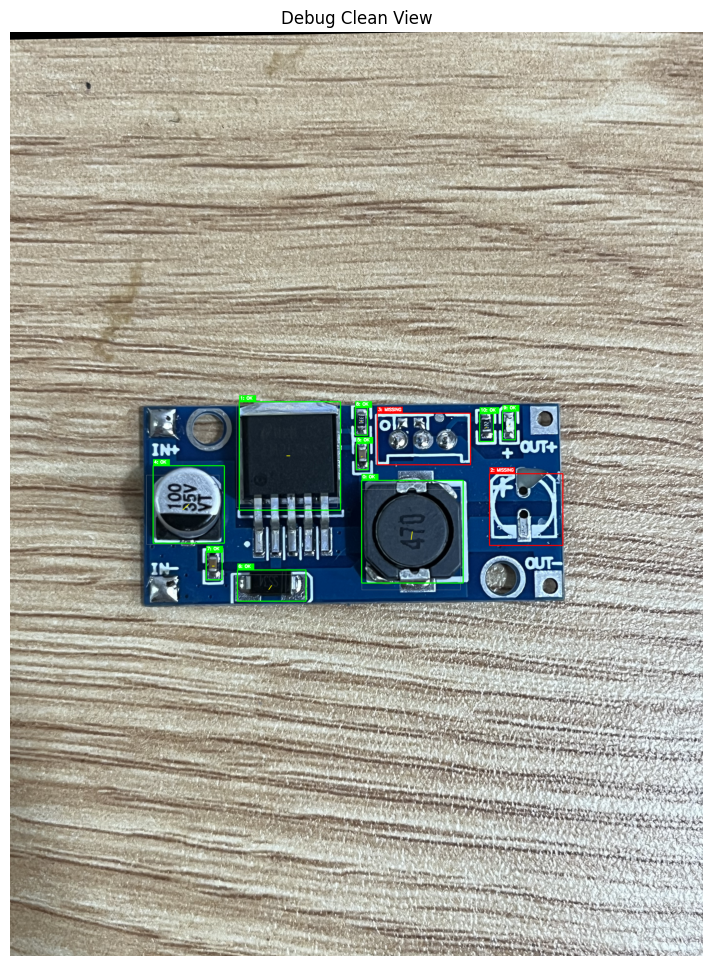

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


class DebugSimInferenceService(SimInferenceService):
    """
    Phiên bản Debug:
    - Matching global best (1-1)
    - Visual rõ ràng, dễ đọc, dễ trace
    """

    # =========================
    # Utils: IoU
    # =========================
    def calculate_iou(self, box1, box2):
        b1_x1, b1_y1 = box1[0] - box1[2]/2, box1[1] - box1[3]/2
        b1_x2, b1_y2 = box1[0] + box1[2]/2, box1[1] + box1[3]/2

        b2_x1, b2_y1 = box2[0] - box2[2]/2, box2[1] - box2[3]/2
        b2_x2, b2_y2 = box2[0] + box2[2]/2, box2[1] + box2[3]/2

        x_left = max(b1_x1, b2_x1)
        y_top = max(b1_y1, b2_y1)
        x_right = min(b1_x2, b2_x2)
        y_bottom = min(b1_y2, b2_y2)

        if x_right <= x_left or y_bottom <= y_top:
            return 0.0

        inter = (x_right - x_left) * (y_bottom - y_top)
        area1 = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
        area2 = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)

        return inter / (area1 + area2 - inter + 1e-6)

    # =========================
    # Utils: Draw label with background
    # =========================
    def draw_label(self, img, text, x, y, color,
                   font_scale=0.6, thickness=2, padding=4):
        font = cv2.FONT_HERSHEY_SIMPLEX
        (tw, th), baseline = cv2.getTextSize(
            text, font, font_scale, thickness
        )

        y = max(y, th + baseline + padding * 2)

        cv2.rectangle(
            img,
            (x, y - th - baseline - padding * 2),
            (x + tw + padding * 2, y),
            color,
            -1
        )

        cv2.putText(
            img,
            text,
            (x + padding, y - baseline - padding),
            font,
            font_scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA
        )

    # =========================
    # Main analyze
    # =========================
    def analyze(self, image):
        print("\n" + "=" * 60)
        print("🚀 DEBUG GLOBAL BEST MATCHING (Visual Clean)")
        print("=" * 60)

        aligned = self.align_image(image)
        h, w = aligned.shape[:2]
        debug_img = aligned.copy()

        # -------------------------
        # YOLO detect
        # -------------------------
        print("📸 YOLO detecting...")
        results = self.model(aligned, conf=0.25, verbose=False)

        detected_candidates = []
        for r in results:
            for i, box in enumerate(r.boxes):
                xywh = box.xywhn[0].tolist()
                conf = float(box.conf[0])

                detected_candidates.append({
                    "id": i,
                    "box": xywh,
                    "conf": conf,
                    "is_used": False
                })

                mx, my, mw, mh = xywh
                x1 = int((mx - mw/2) * w)
                y1 = int((my - mh/2) * h)
                x2 = int((mx + mw/2) * w)
                y2 = int((my + mh/2) * h)

                # YOLO box (xanh dương)
                cv2.rectangle(debug_img, (x1, y1), (x2, y2), (255, 0, 0), 1)

        print(f"YOLO candidates: {len(detected_candidates)}")

        # -------------------------
        # Step 1: build potential matches
        # -------------------------
        potential_matches = []

        for comp in self.profile.components:
            tx, ty, tw, th = comp.box

            # Template box (xám)
            x1t = int((tx - tw/2) * w)
            y1t = int((ty - th/2) * h)
            x2t = int((tx + tw/2) * w)
            y2t = int((ty + th/2) * h)
            cv2.rectangle(debug_img, (x1t, y1t), (x2t, y2t),
                          (160, 160, 160), 1)

            for cand in detected_candidates:
                iou = self.calculate_iou(comp.box, cand["box"])
                dx, dy, _, _ = cand["box"]
                dist = np.sqrt((tx - dx) ** 2 + (ty - dy) ** 2)

                if iou > 0.01 or dist < 0.15:
                    score = iou + (2.0 - dist)
                    potential_matches.append({
                        "comp_id": comp.id,
                        "comp_box": comp.box,
                        "cand": cand,
                        "iou": iou,
                        "dist": dist,
                        "score": score
                    })

        potential_matches.sort(key=lambda x: x["score"], reverse=True)

        # -------------------------
        # Step 2: greedy matching
        # -------------------------
        matched = {}
        used_comps = set()

        for m in potential_matches:
            cid = m["comp_id"]
            cand = m["cand"]

            if cid in used_comps or cand["is_used"]:
                continue

            matched[cid] = m
            cand["is_used"] = True
            used_comps.add(cid)

            print(
                f"✅ Comp {cid} ↔ Box {cand['id']} "
                f"(IoU={m['iou']:.2f}, Dist={m['dist']:.2f})"
            )

        # -------------------------
        # Step 3: visualize result
        # -------------------------
        missing = []

        for comp in self.profile.components:
            if comp.id not in matched:
                missing.append(comp.id)

                tx, ty, tw, th = comp.box
                x1 = int((tx - tw/2) * w)
                y1 = int((ty - th/2) * h)
                x2 = int((tx + tw/2) * w)
                y2 = int((ty + th/2) * h)

                cv2.rectangle(debug_img, (x1, y1), (x2, y2),
                              (0, 0, 255), 3)
                self.draw_label(debug_img, f"{comp.id}: MISSING",
                                x1, y1, (0, 0, 255))
                continue

            m = matched[comp.id]
            cand = m["cand"]

            mx, my, mw, mh = cand["box"]
            x1 = int((mx - mw/2) * w)
            y1 = int((my - mh/2) * h)
            x2 = int((mx + mw/2) * w)
            y2 = int((my + mh/2) * h)

            # Line connect (vàng)
            tx, ty, _, _ = comp.box
            cv2.line(
                debug_img,
                (int(tx * w), int(ty * h)),
                (int(mx * w), int(my * h)),
                (0, 255, 255),
                2,
                cv2.LINE_AA
            )

            vis_score = self.verify_visual(aligned, cand["box"])
            conf = cand["conf"]

            if vis_score > 0.15 or conf > 0.50:
                ok = True
                label = f"{comp.id}: OK "
                color = (0, 255, 0)
            else:
                ok = False
                label = f"{comp.id}: BAD "
                color = (0, 0, 255)

            cv2.rectangle(debug_img, (x1, y1), (x2, y2), color, 3)
            self.draw_label(debug_img, label, x1, y1, color)

        return debug_img, missing


# =========================
# Run test
# =========================
debug_inferencer = DebugSimInferenceService()

if "test_img_bgr" in globals():
    result_img, missing_ids = debug_inferencer.analyze(test_img_bgr)

    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title("Debug Clean View")
    plt.axis("off")
    plt.show()
else:
    print("⚠️ Chưa có test_img_bgr")
